# Quantum Pattern Generation — FRQI
In the first challenge, Quantum Image Lab: The FRQI Challenge, you were introduced to the FRQI encoding of an image into a quantum state.

It is now time to deep dive into the transformation and generation of quantum visuals using the FRQI encoding.
You will be given target patterns and tasked to build a FRQI circuit that can reproduce them.

### Challenge Outline
1. **Random Noise**

2. **Quantum Checkerboard**

3. **Horizontal and vertical lines**

4. **Nested Squares**

5. **Grayscale Nested Squares**

6. **Quantum Fractals** *(bonus)*


In [1]:
import math
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Import utility functions
import utils_quantum
importlib.reload(utils_quantum)
from utils_quantum import run_simulation
from utils_images import display_image

## Pattern 1 - Random Noise
You must produce a fully random image, like TV static. Each pixel is drawn independently from the others, with a 50% chance of being black and a 50% chance of being white. Here are 4 examples of what we're looking for:

![random_pattern.png](images/random_noise.png)

[[1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1.]
 [1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0.]
 [0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.]
 [0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0.]
 [1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1.]]


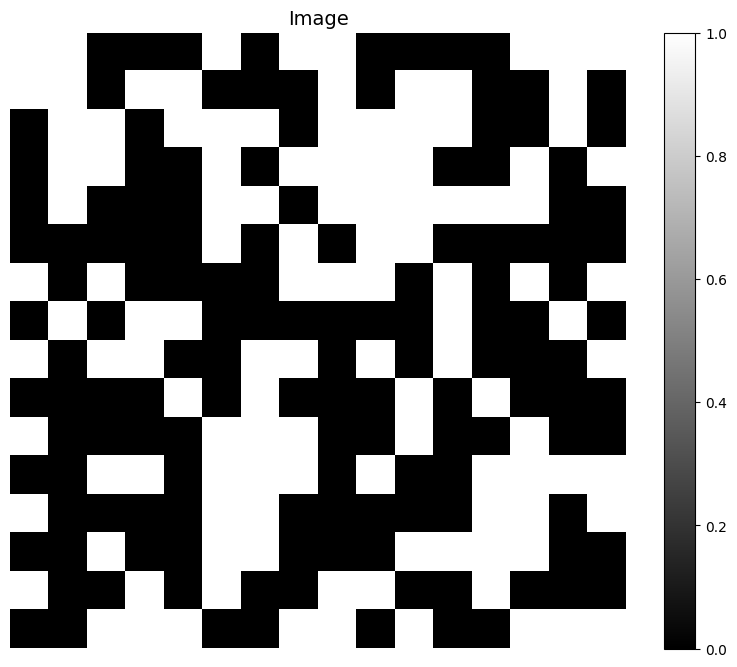

In [18]:
from qiskit_aer import AerSimulator
from qiskit import transpile

L1 = 16
L2 = 16
bits = []
for _ in range(L1*L2):
    qc  = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()

    
    sampler = AerSimulator(method="statevector")
    outcome_hex = list(
        sampler.run([qc.decompose(reps=1)], shots=1)
        .result()
        .data(0)["counts"]
        .keys()
    )[0]
    outcome_binary = format(int(outcome_hex, 16), f"0{1}b")
    bits.append(outcome_binary)

bm = np.array(bits).reshape(L1,L2).astype(float)
print(bm)
display_image(bm)

## Pattern 2 - Quantum Checkerboard

Create a classic checkerboard pattern, that is, alternating black and white pixels. The circuit is **deterministic**: it always produces the same checkerboard.

Can you also figure out how to obtain the negative from this first circuit?

![chess](images/chess.png)

Note: the checkerboard and its negative are reconstructed separately, using distinct circuits.

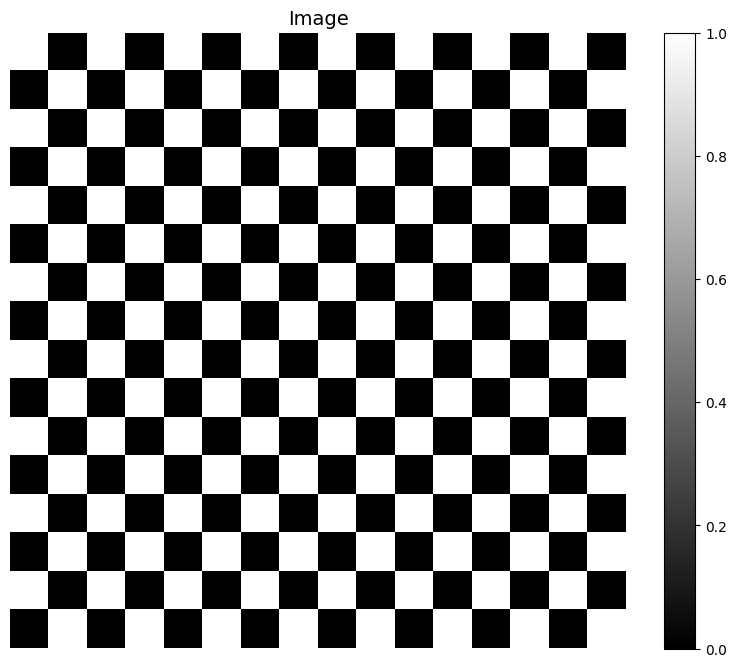

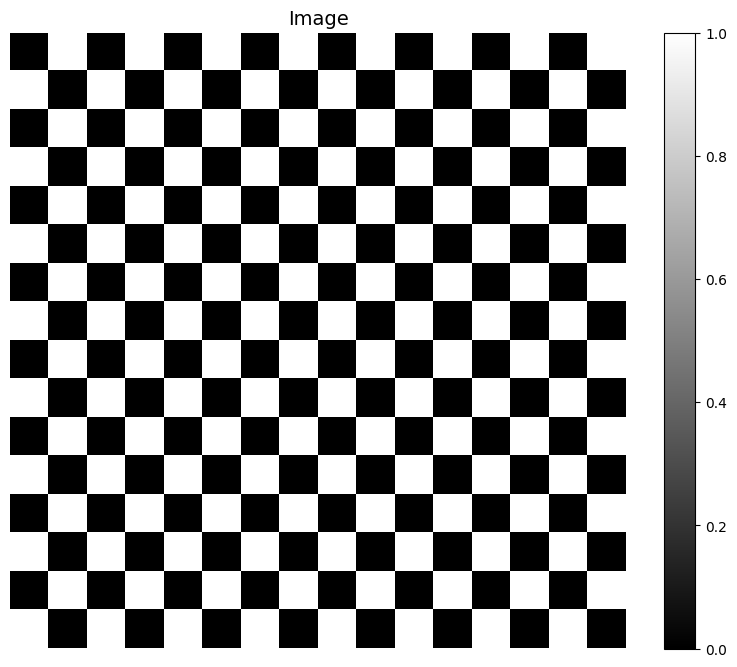

In [36]:
L1 = 16
L2 = 16
qc  = QuantumCircuit(L1*L2)
for q in range(L1*L2):
    if q//L1%2==0:
        if q%2==0: 
            qc.x(q)
    elif q%2==1:
        qc.x(q)

qc.measure_all()
qc.draw()

sampler = AerSimulator(method="matrix_product_state")
outcome_hex = list(
    sampler.run([qc.decompose(reps=1)], shots=1)
    .result()
    .data(0)["counts"]
    .keys()
)[0]

outcome_binary = format(int(outcome_hex, 16), f"0{L1*L2}b")
bits = [b for b in outcome_binary]

bm = np.array(bits).reshape(L1,L2).astype(float)
bmi = 1-bm
display_image(bm)
display_image(bmi)

## Pattern 3 - Horizontal Lines
You must generate alternating black and white horizontal lines that remain the same between each run.

![Horizontal lines](images/frqi_bar_horiz.png)

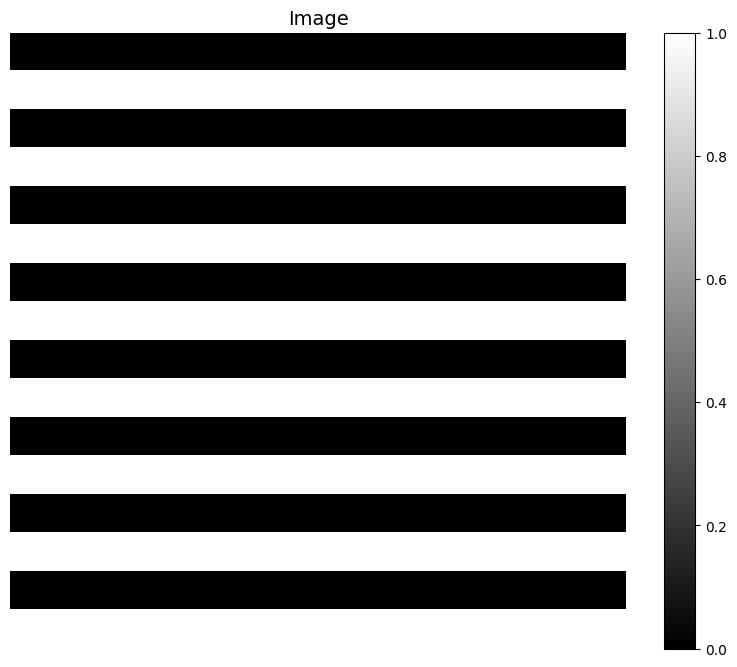

In [38]:
L1 = 16
L2 = 16
qc  = QuantumCircuit(L1*L2)
for q in range(L1*L2):
    if q//L1%2==0: 
        qc.x(q)

qc.measure_all()
qc.draw()

sampler = AerSimulator(method="matrix_product_state")
outcome_hex = list(
    sampler.run([qc.decompose(reps=1)], shots=1)
    .result()
    .data(0)["counts"]
    .keys()
)[0]

outcome_binary = format(int(outcome_hex, 16), f"0{L1*L2}b")
bits = [b for b in outcome_binary]

bm = np.array(bits).reshape(L1,L2).astype(float)
display_image(bm)

## Pattern 4 - Vertical Lines
Same idea as pattern 3, but the lines must be vertical just like in the picture below.

![Vertical lines](images/frqi_bar_ver.png)

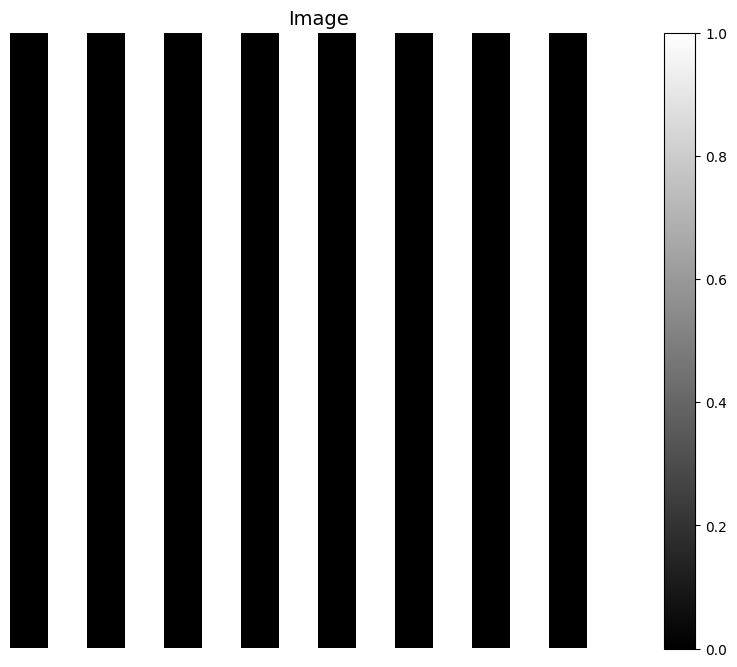

In [39]:
L1 = 16
L2 = 16
qc  = QuantumCircuit(L1*L2)
for q in range(L1*L2):
    if q%2==0:
        qc.x(q)

qc.measure_all()
qc.draw()

sampler = AerSimulator(method="matrix_product_state")
outcome_hex = list(
    sampler.run([qc.decompose(reps=1)], shots=1)
    .result()
    .data(0)["counts"]
    .keys()
)[0]

outcome_binary = format(int(outcome_hex, 16), f"0{L1*L2}b")
bits = [b for b in outcome_binary]

bm = np.array(bits).reshape(L1,L2).astype(float)
display_image(bm)

## Pattern 5 - Nested Squares

Here, we want to build concentric rectangles, that is, nested squares that alternate black and white from the outside toward the center. In contrast to the checkerboard and the stripes patterns, each pixel must be handled individually.

To describe this pattern, we consider an image of size $R \times C$:
- $R$ = number of rows
- $C$ = number of columns

For a pixel located at row $r$ and column $c$, we define its **layer** $L(r,c)$ as its distance to the nearest border:

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Thus:
- layer $0$ corresponds to the outer border,
- layer $1$ to the first inner rectangle,
- layer $2$ to the next one,
- and so on until the center.

**Your goal:** find an FRQI circuit that reproduces this pattern while respecting the black/white alternation.

![Concentric rectangles](images/frqi_carre.png)

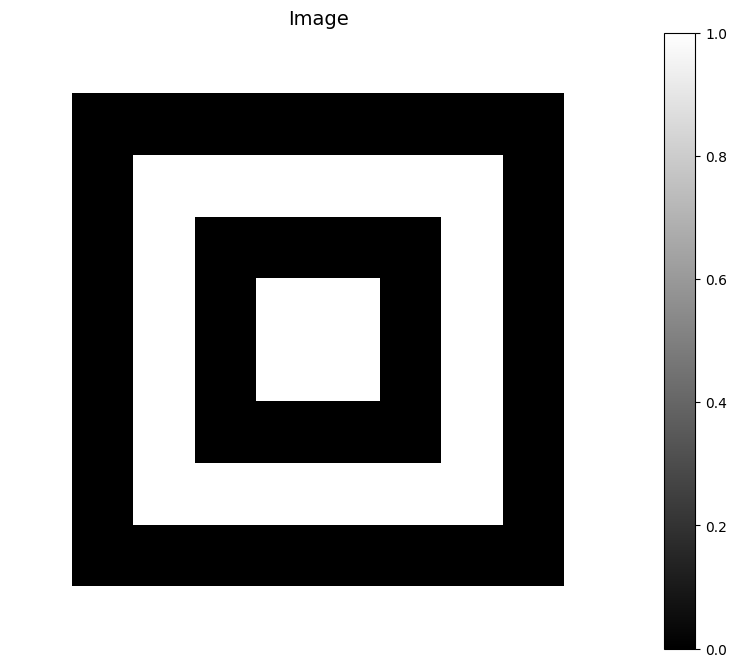

In [40]:
L1 = 10
L2 = 10
def layer(r,c,R,C):
    return min(r,c,R-1-r,C-1-c)

qc  = QuantumCircuit(L1*L2)
for q in range(L1*L2):
    if layer(q//L1, q%L2, L1,L2)%2==0:
        qc.x(q)

qc.measure_all()
qc.draw()

sampler = AerSimulator(method="matrix_product_state")
outcome_hex = list(
    sampler.run([qc.decompose(reps=1)], shots=1)
    .result()
    .data(0)["counts"]
    .keys()
)[0]

outcome_binary = format(int(outcome_hex, 16), f"0{L1*L2}b")
bits = [b for b in outcome_binary]

bm = np.array(bits).reshape(L1,L2).astype(float)
display_image(bm)


## Pattern 6 - Grayscale Nested Squares

Same idea as the Nested Squares in pattern 5, but **each layer has a different intensity**.
You can find how to handle grayscale images using FRQI encoding in challenge 1 Image Lab.

![Grayscale rectangles](images/frqi_carre_gris.png)

/home/ludo/Hackathons/compile-moi-si-tu-peux/iqucodefest-2026-docs/side_quests/challenge_01_quantum_vision_fundamentals
['frqi_challenge_en.ipynb', 'utils_images.py', 'utils_quantum.py', 'frqi_challenge_fr.ipynb', 'grayscale.py', '__pycache__']
[[255. 255. 255. 255. 255. 255. 255. 255. 255. 255.]
 [255. 204. 204. 204. 204. 204. 204. 204. 204. 255.]
 [255. 204. 153. 153. 153. 153. 153. 153. 204. 255.]
 [255. 204. 153. 102. 102. 102. 102. 153. 204. 255.]
 [255. 204. 153. 102.  51.  51. 102. 153. 204. 255.]
 [255. 204. 153. 102.  51.  51. 102. 153. 204. 255.]
 [255. 204. 153. 102. 102. 102. 102. 153. 204. 255.]
 [255. 204. 153. 153. 153. 153. 153. 153. 204. 255.]
 [255. 204. 204. 204. 204. 204. 204. 204. 204. 255.]
 [255. 255. 255. 255. 255. 255. 255. 255. 255. 255.]]
Note: 2^k = 128 > N = 100 (extra addresses stay white)
 FRQI circuit created!
   Depth: 17401, Size: 20975 gates
Reconstructing image from measurements...


Reconstructed image:
[[255 255 255 255 255 255 255 255 255 255]
 [2

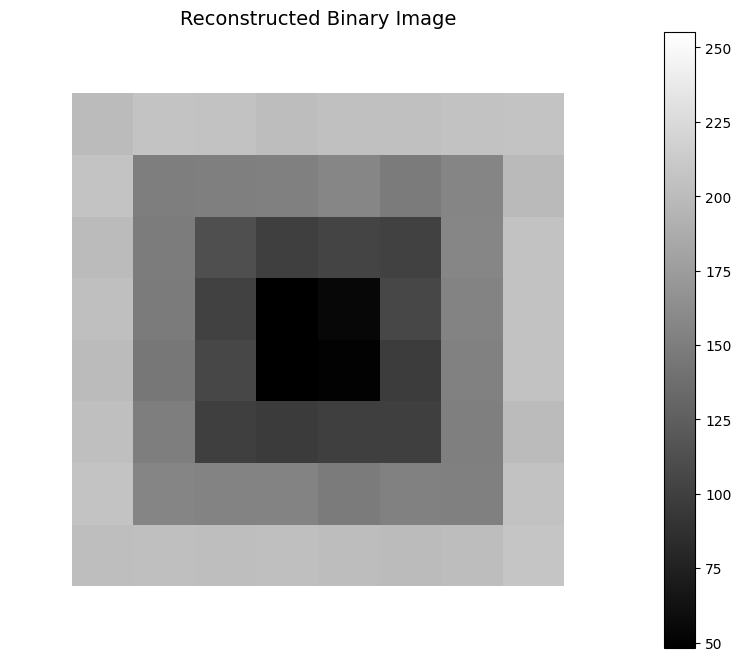

In [74]:
import os
import sys

base = os.path.dirname(os.getcwd())
grandparent = os.path.dirname(base)

notebook_dir = os.path.join(grandparent,"side_quests" ,"challenge_01_quantum_vision_fundamentals")
notebook_name = "frqi_challenge_fr"   # without .ipynb

# Add the folder to sys.path
sys.path.append(notebook_dir)
print(notebook_dir)
print(os.listdir(notebook_dir))

from grayscale import encode_frqi_grayscale, reconstruct_grayscale_from_frqi

L1 = 10
L2 = 10
def layer(r,c,R,C):
    return min(r,c,R-1-r,C-1-c)

n_layers = L1//2

grayscale = np.zeros((L1,L2))
for q in range(L1*L2):
    l = layer(q//L1, q%L2, L1,L2)
    grayscale[q//L1, q%L2] = 255 - l/n_layers*255
print(grayscale)

# Build FRQI circuit
frqi_circuit, n_pos = encode_frqi_grayscale(grayscale)

# very important: add measurement to the circuit
frqi_circuit.measure_all()

num_shots = 1000 * (2**n_pos) # 200 shots per pixel address
counts = utils_quantum.run_simulation(frqi_circuit, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_grayscale_from_frqi(counts, n_pos, grayscale.shape)

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

display_image(frqi_reconstructed, "Reconstructed Binary Image")

## Pattern 7 - Quantum Sierpiński Triangle (Bonus)
This challenge consists of building **a single FRQI circuit** that allows you to reconstruct:
- the **normal** image;
- the **inverted** image.

![Sierpiński triangle](images/fractal.png)

The idea is that after taking **many measurements**, you obtain **two groups of results** depending on the value of a **selection qubit**, and then you reconstruct one image per group.

The **classical mask** necessary to build the fractal is given below.

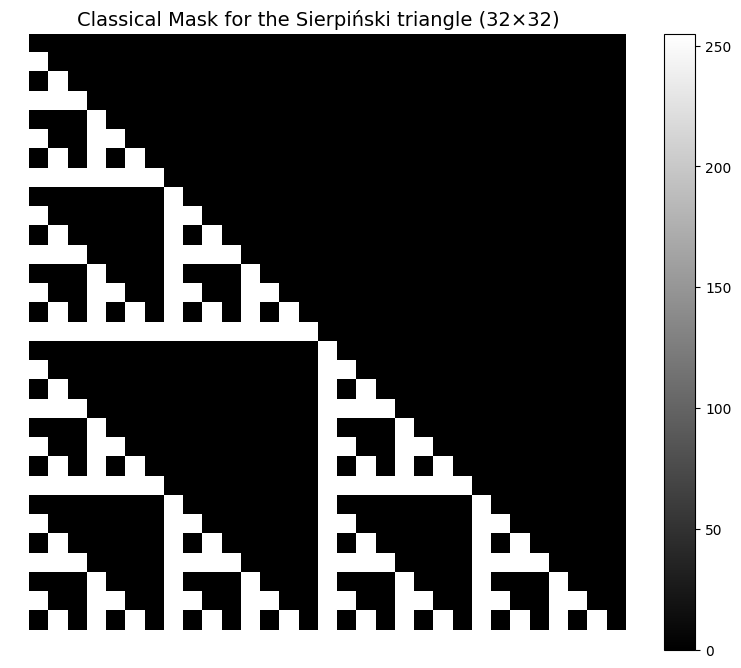

In [41]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Classical Mask for the Sierpiński triangle ({size}×{size})", cmap='gray')

[[1 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [1 1 0 ... 1 0 0]
 [1 0 1 ... 0 1 0]
 [1 1 1 ... 1 1 1]]


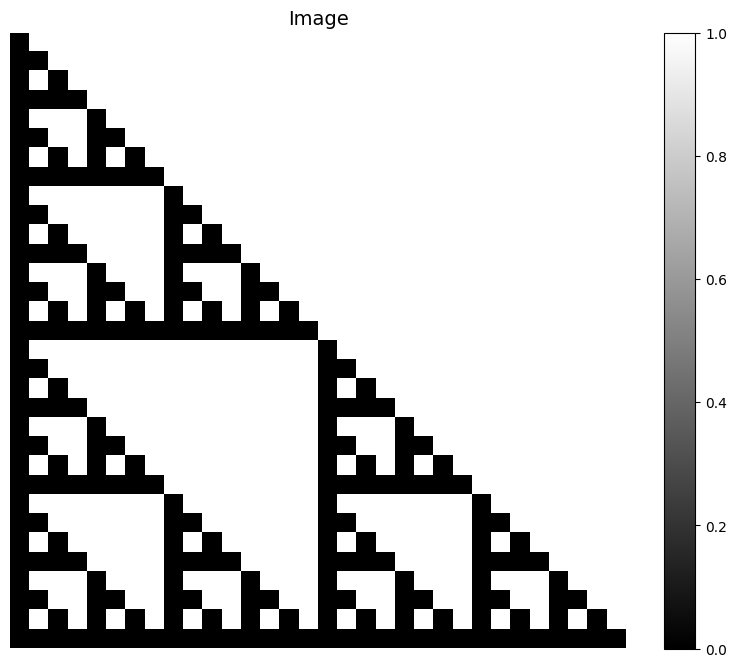

In [47]:
L1 = 32
L2 = 32

mask = sierpinski_triangle_mask(L1)

print(mask)

qc = QuantumCircuit(L1*L2)
for q in range(L1*L2):
    if mask[q//L1, q%L2] == 0:
        qc.x(q)

qc.measure_all()

sampler = AerSimulator(method="matrix_product_state")
outcome_hex = list(
    sampler.run([qc.decompose(reps=1)], shots=1)
    .result()
    .data(0)["counts"]
    .keys()
)[0]

outcome_binary = format(int(outcome_hex, 16), f"0{L1*L2}b")
bits = [b for b in outcome_binary]

bm = np.array(bits).reshape(L1,L2).astype(float).T
display_image(bm)
